<a href="https://colab.research.google.com/github/siinwook/Deep-Learning-from-Scratch/blob/main/ch07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install import_ipynb
import sys, import_ipynb

from google.colab import drive
drive.mount('/content/drive')

%cd "__path__"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

im2col

In [ ]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0): #(N,C,H,W) -> (N*outH*outW,C*FH*FW)
  N,C,H,W = input_data.shape

  out_h = (H + 2*pad - filter_h)//stride + 1
  out_w = (W + 2*pad - filter_w)//stride + 1

  img = np.pad(input_data, [(0,0), (0,0), (pad, pad), (pad, pad)], 'constant')
  col = np.zeros((N,C,filter_h,filter_w,out_h,out_w)) #(N,C,FH,FW,outH,outW)

  for y in range(filter_h):
    y_max = y + stride*out_h
    for x in range(filter_w):
      x_max = x + stride*out_w
      col[:,:,y,x,:,:] = img[:,:,y:y_max:stride,x:x_max:stride]

  col = col.transpose(0,4,5,1,2,3).reshape(N*out_h*out_w,-1) #(N,C,FH,FW,outH,outW) -> (N,outH,outW,C,FH,FW) -> (N*outH*outW,C*FH*FW)
  return col #(N*outH*outW,C*FH*FW)

col2im

In [ ]:
def col2im(col, input_size, filter_h, filter_w, stride=1, pad=0): #(N*outH*outW,C*FH*FW) -> (N,C,H,W)
  N,C,H,W = input_size
  out_h = (H + 2*pad - filter_h)//stride + 1
  out_w = (W + 2*pad - filter_w)//stride + 1
  col = col.reshape(N,out_h,out_w,C,filter_h,filter_w).transpose(0,3,4,5,1,2) #(N*outH*outW,C*FH*FW) -> (N,outH,outW,C,FH,FW) -> (N,C,FH,FW,outH,outW)

  img = np.zeros((N, C, H + 2*pad + stride - 1, W + 2*pad + stride - 1))
  for y in range(filter_h):
    y_max = y + stride*out_h
    for x in range(filter_w):
      x_max = x + stride*out_w
      img[:,:,y:y_max:stride,x:x_max:stride] += col[:,:,y,x,:,:] #spread gradient (filter[y,x]) to each related pixel of img

  return img[:,:,pad:H+pad,pad:W+pad] #(N,C,H,W)

Convolution layer

In [ ]:
class Convolution:
  def __init__(self, W,b,stride=1,pad=0):
    self.W = W #(FN,C,FH,FW)
    self.b = b #(FN)
    self.stride = stride
    self.pad = pad

    self.dW=None
    self.db=None

    #for backward
    self.x=None
    self.col=None
    self.col_W=None

  def forward(self,x): #(N,C,H,W) -> (N,FN,outH,outW)
    N,C,W,H = x.shape
    FN,C,FH,FW = self.W.shape

    out_h = int((H + 2*self.pad - FH)/ self.stride + 1)
    out_w = int((W + 2*self.pad - FW)/ self.stride + 1)

    col = im2col(x,FH,FW,self.stride,self.pad) #(N,C,H,W) -> (N*outH*outW,C*FH*FW)
    col_W = self.W.reshape(FN,-1).T #(FN,C*FH*FW) -> (C*FH*FW,FN)

    out = np.dot(col,col_W) + self.b #(N*outH*outW,C*FH*FW) dot (C*FH*FW,FN) -> (N*outH*outW,FN)
    out = out.reshape(N,out_h,out_w,-1).transpose(0,3,1,2) #(N*outH*outW,FN) -> (N,outH,outW,FN) -> (N,FN,outH,outW)

    self.x = x
    self.col = col
    self.col_W = col_W

    return out #(N,FN,outH,outW)

  def backward(self, dout): #(N,FN,outH,outW) -> (N,C,H,W)
    FN,C,FW,FH = self.W.shape
    dout = dout.transpose(0,2,3,1).reshape(-1,FN) #(N,FN,outH,outW) -> (N,outH,outW,FN) -> (N*outH*outW,FN)

    self.db = np.sum(dout, axis=0)
    self.dW = np.dot(self.col.T, dout) #(C*FH*FW,N*outH*outW) dot (N*H*W,FN) -> (C*FH*FW,FN)
    self.dW = self.dW.transpose(1,0).reshape(FN,C,FH,FW) #(C*FH*FW,FN) -> (FN,C*FH*FW) -> (FN,C,FH,FW)

    dcol = np.dot(dout, self.col_W.T) #(N*outH*outW,FN) dot (FN,C*FH*FW) -> (N*outH*outW,C*FH*FW)
    dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad) #(N*outH*outW,C*FH*FW) -> (N,C,H,W)

    return dx #(N,C,H,W)

Pooling layer

In [ ]:
class Pooling:
  def __init__(self,pool_h,pool_w,stride=1,pad=0):
    self.pool_h = pool_h
    self.pool_w = pool_w
    self.stride = stride
    self.pad = pad

    self.x = None
    self.arg_max = None
  def forward(self, x): #(N,C,H,W) -> (N,C,outH,outW)
    N,C,H,W = x.shape
    out_h = int(1+ (H - self.pool_h) / self.stride)
    out_w = int(1+ (W - self.pool_w) / self.stride)

    col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad) #(N,C,H,W) -> (N*outH*outW,C*FH*FW)
    col = col.reshape(-1, self.pool_h * self.pool_w) #(N*outH*outW,C*FH*FW) -> (N*outH*outW*C,FH*FW)

    self.arg_max = np.argmax(col, axis=1) #(N*outH*outW*C,)
    out = np.max(col, axis=1) #(N*outH*outW*C,FH*FW) -> (N*outH*outW*C,)

    out = out.reshape(N, out_h, out_w, C).transpose(0,3,1,2) #(N*outH*outW*C,) -> (N,outH,outW,C) -> (N,C,outH,outW)

    self.x = x
    return out #(N,C,outH,outW)

  def backward(self, dout): #(N,C,outH,outW) -> (N,C,H,W)
    dout = dout.transpose(0,2,3,1) #(N,C,outH,outW) -> (N,outH,outW,C)

    pool_size = self.pool_h * self.pool_w
    dmax = np.zeros((dout.size, pool_size)) #(N*outH*outW*C,FH*FW)
    dmax[np.arange(self.arg_max.size),self.arg_max.flatten()] = dout.flatten() #put dout into dmax[:,index of max element]
    dmax = dmax.reshape(dout.shape + (pool_size,)) #(N*outH*outW*C,FH*FW)

    dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1) #(N*outH*outW*C,FH*FW) -> (N*outH*outW,C*FH*FW)
    dx = col2im(dcol, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad) #(N*outH*outW,C*FH*FW) -> (N,C,H,W)

    return dx #(N,C,H,W)

simple CNN

In [ ]:
from collections import OrderedDict
from layers import *
class SimpleConvNet:
  """
  conv - relu - pool-
  fully connected - relu -
  fully connected - softmax
  """
  def __init__(self,input_dim=(1,28,28),conv_param={'filter_num' : 30, 'filter_size' : 5, 'pad' : 0, 'stride' : 1}, hidden_size = 100, output_size = 10, weight_init_std = 0.01):
    filter_num = conv_param['filter_num']
    filter_size = conv_param['filter_size']
    filter_pad = conv_param['pad']
    filter_stride = conv_param['stride']
    input_size = input_dim[1]
    conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
    pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

    self.params={}
    #Convolution layer
    self.params['W1'] = weight_init_std * np.random.randn(filter_num,input_dim[0],filter_size,filter_size)
    self.params['b1'] = np.zeros(filter_num)
    #fully connected layer
    self.params['W2'] = weight_init_std * np.random.randn(pool_output_size,hidden_size)
    self.params['b2'] = np.zeros(hidden_size)
    #softmax layer
    self.params['W3'] = weight_init_std * np.random.randn(hidden_size,output_size)
    self.params['b3'] = np.zeros(output_size)

    self.layers = OrderedDict()
    self.layers['Conv1'] = Convolution(self.params['W1'],self.params['b1'],filter_stride,filter_pad)
    self.layers['Relu1'] = Relu()
    self.layers['Pool1'] = Pooling(pool_h =2, pool_w=2, stride=2)
    self.layers['Affine1'] = Affine(self.params['W2'],self.params['b2'])
    self.layers['Relu2'] = Relu()
    self.layers['Affine2'] = Affine(self.params['W3'],self.params['b3'])

    self.last_layer = SoftmaxWithLoss()

  def predict(self,x):
    for layer in self.layers.values():
      x = layer.forward(x)
    return x

  def loss(self,x,t):
    y = self.predict(x)
    return self.last_layer.forward(y,t)

  def accuracy(self, x, t):
      y = self.predict(x)
      y = np.argmax(y, axis=1)

      if t.ndim != y.ndim:
        t = np.argmax(t, axis=1)

      accuracy = np.sum(y==t).astype(int) / float(x.shape[0])
      return accuracy

  def gradient(self,x,t):
    self.loss(x,t)

    dout=1
    dout = self.last_layer.backward(dout)

    layers = list(self.layers.values())
    layers.reverse()
    for layer in layers:
      dout = layer.backward(dout)

    grads={}
    grads['W1'] = self.layers['Conv1'].dW
    grads['b1'] = self.layers['Conv1'].db
    grads['W2'] = self.layers['Affine1'].dW
    grads['b2'] = self.layers['Affine1'].db
    grads['W3'] = self.layers['Affine2'].dW
    grads['b3'] = self.layers['Affine2'].db

    return grads

mini batch training

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from optimizers import Adam
import tqdm

(x_train, t_train), (x_test, t_test) = mnist.load_data()
x_train, t_train = x_train[:10000], t_train[:10000]
x_test, t_test = x_test[:2000], t_test[:2000]
x_train = x_train.reshape(10000,1,28,28)
x_test = x_test.reshape(2000,1,28,28)
x_train = x_train/255.0
x_test = x_test/255.0
t_train = to_categorical(t_train, 10).astype(int) # one-hot encoding
t_test = to_categorical(t_test, 10).astype(int)

train_loss_list = []
train_acc_list = []
test_acc_list = []

#hyper parameter
iters_num = 1000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.001

network = SimpleConvNet()
optimizer = Adam()

iter_per_epoch = max(train_size / batch_size, 1)

for i in tqdm.tqdm(range(iters_num)):
  batch_mask = np.random.choice(train_size,batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  grad = network.gradient(x_batch, t_batch)

  optimizer.update(network.params, grad)

  loss = network.loss(x_batch, t_batch)
  train_loss_list.append(loss)

  # accuracy per epoch (epoch: # of iteration using whole set)
  if i % iter_per_epoch == 0:
    train_acc = network.accuracy(x_train, t_train)
    test_acc = network.accuracy(x_test, t_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

  0%|          | 1/1000 [00:26<7:13:34, 26.04s/it]

train acc, test acc | 0.352, 0.357


 10%|█         | 101/1000 [01:37<1:37:03,  6.48s/it]

train acc, test acc | 0.9019, 0.8805


 20%|██        | 201/1000 [02:40<1:07:19,  5.06s/it]

...

 80%|████████  | 801/1000 [08:54<15:49,  4.77s/it]

train acc, test acc | 0.9818, 0.958


 90%|█████████ | 901/1000 [09:57<07:55,  4.81s/it]

train acc, test acc | 0.9829, 0.959


100%|██████████| 1000/1000 [10:45<00:00,  1.55it/s]


train / test accuracy

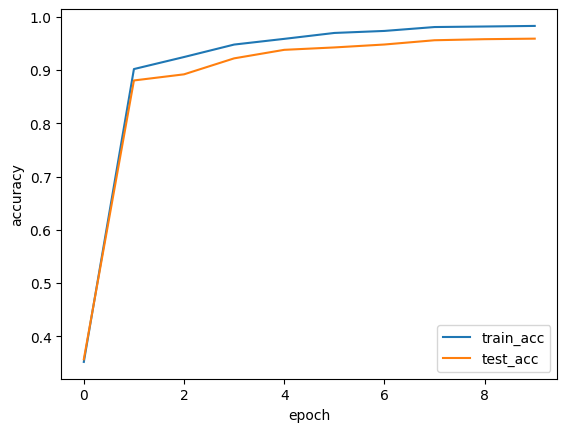

In [ ]:
plt.plot(train_acc_list)
plt.plot(test_acc_list)
plt.legend(['train_acc','test_acc'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()
#high accuracy considering its simple network

loss

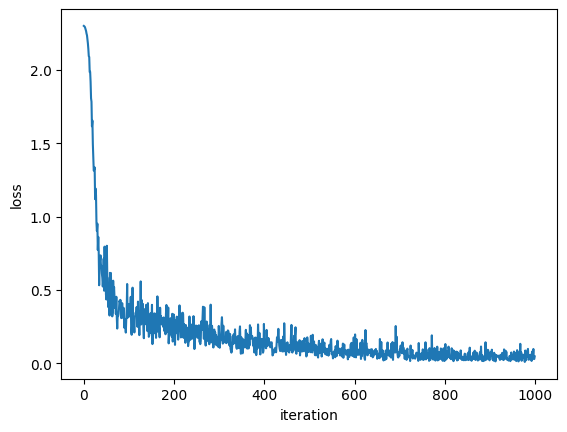

In [ ]:
plt.plot(train_loss_list)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.show()